In [1]:
%load_ext autoreload
%autoreload 2
import physquirrel as sq
import random       
import numpy as np

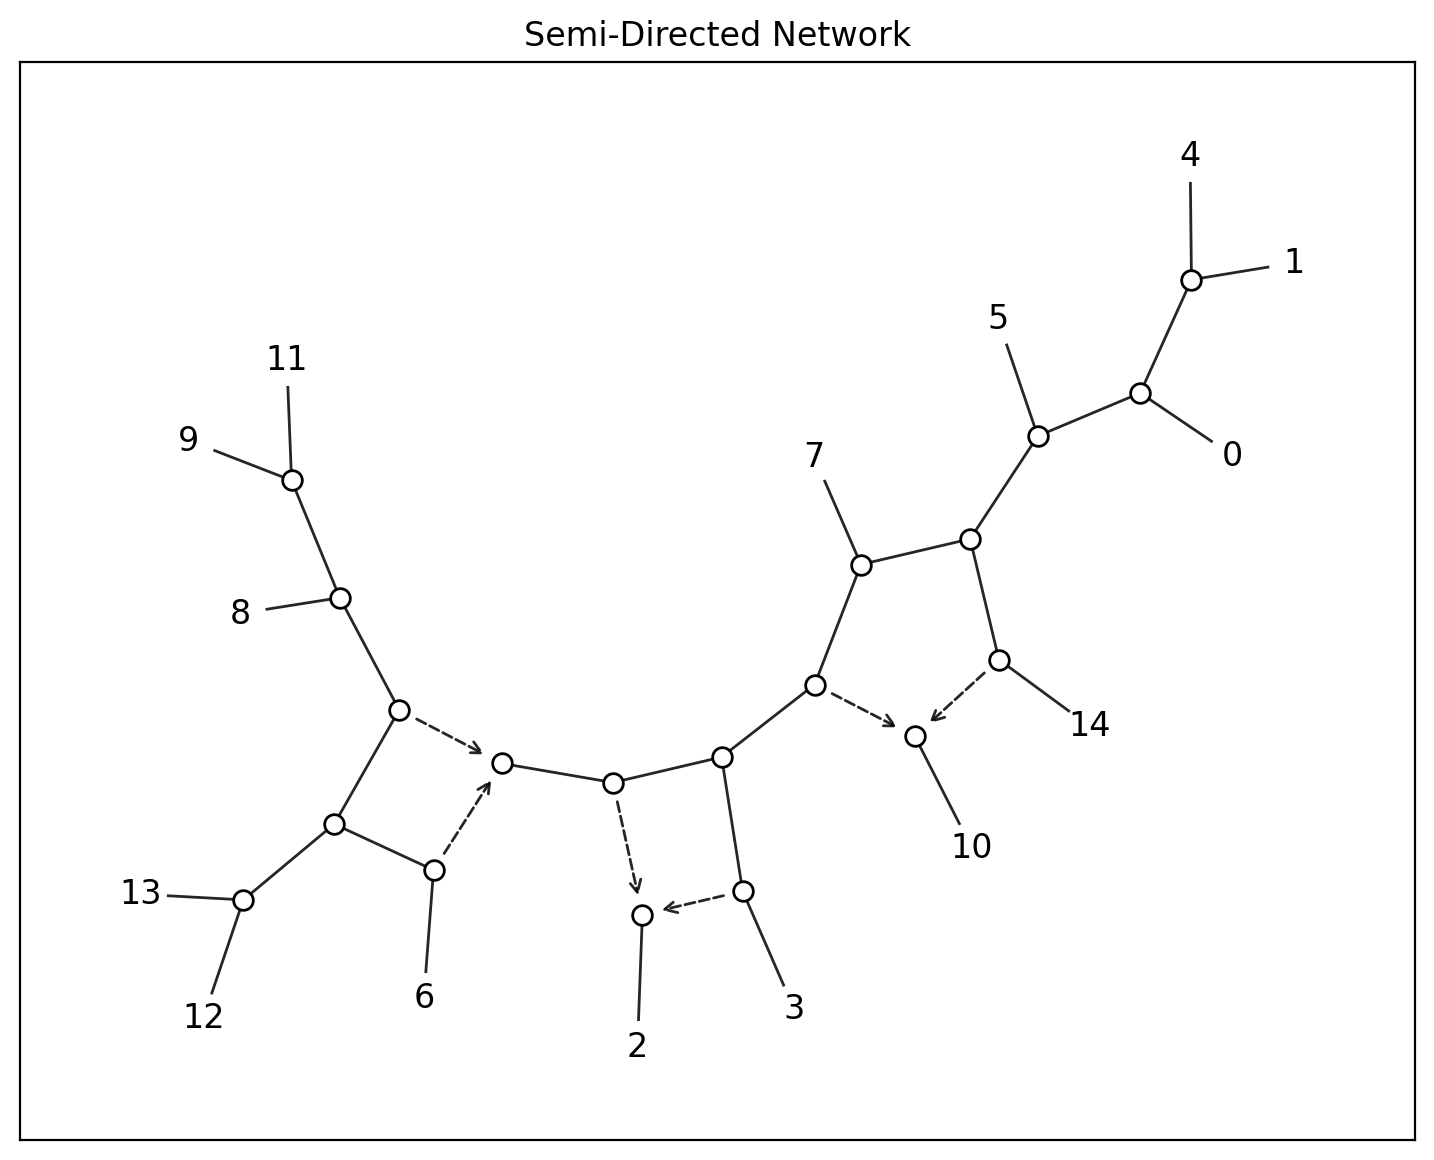

<Axes: title={'center': 'Semi-Directed Network'}>

In [2]:
seed = 348957
random.seed(seed)
np.random.seed(seed)
#7,1
N = sq.sdnetwork.random_semi_directed_network(15, 3)
N.visualize()

DenseQuarnetSet[(SQ: 13 12 | 1 5), (SQ: 1 10 | 11 12), (SQ: 5 3 | 9 6), (4C: *7*-6-13-9), (SQ: 8 3 | 7 5), (SQ: 7 2 | 11 13), (SQ: 7 12 | 9 8), (SQ: 3 0 | 6 12), (SQ: 4 5 | 11 13), (SQ: 13 12 | 1 2), (SQ: 14 7 | 11 8), (SQ: 1 5 | 8 13), (SQ: 5 0 | 10 3), (SQ: 4 1 | 10 0), (SQ: 4 2 | 6 12), (SQ: 14 0 | 9 6), (SQ: 11 2 | 10 0), (SQ: 5 0 | 14 10), (SQ: 11 3 | 1 5), (SQ: 4 5 | 9 13), (SQ: 4 1 | 14 3), (SQ: 11 10 | 1 0), (SQ: 1 2 | 8 13), (SQ: 13 12 | 14 1), (SQ: 6 3 | 14 10), (SQ: 14 3 | 11 12), (SQ: 14 3 | 11 13), (SQ: 11 7 | 4 0), (SQ: 13 0 | 9 11), (SQ: 9 7 | 1 0), (4C: *10*-14-5-6), (4C: *14*-6-13-11), (SQ: 4 1 | 6 5), (SQ: 14 3 | 8 12), (SQ: 6 3 | 1 5), (SQ: 4 1 | 14 12), (SQ: 7 10 | 8 12), (SQ: 11 3 | 14 1), (SQ: 5 0 | 6 10), (SQ: 4 3 | 6 13), (4C: *10*-14-5-9), (SQ: 8 2 | 14 0), (SQ: 1 5 | 6 12), (SQ: 4 3 | 8 13), (SQ: 10 3 | 11 6), (SQ: 6 2 | 5 0), (SQ: 8 3 | 4 10), (SQ: 13 3 | 1 5), (SQ: 4 0 | 9 11), (SQ: 14 9 | 1 0), (SQ: 7 5 | 8 6), (SQ: 13 12 | 11 10), (SQ: 4 5 | 6 13), (SQ: 3 

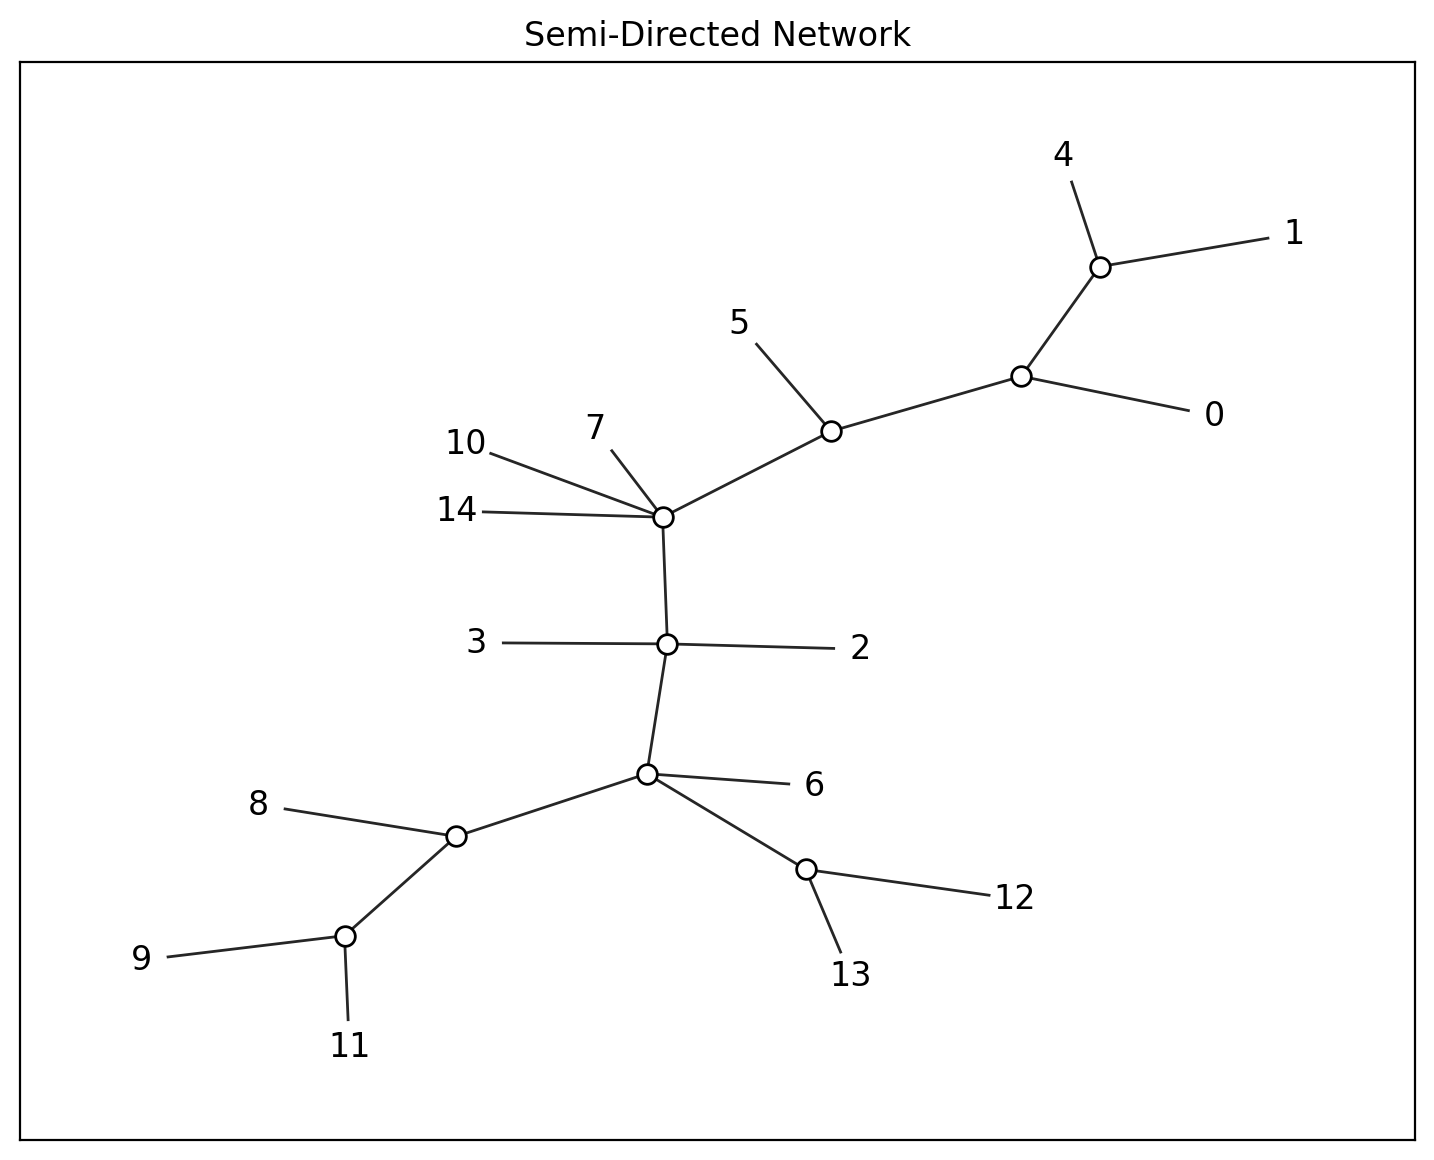

<Axes: title={'center': 'Semi-Directed Network'}>

In [3]:
Q, Q_splits = N.quarnets(triangles=False, return_4splits=True)
print(Q)
N_blob = N.blobtree()
N_blob.visualize()

In [4]:
Q_shake = Q._shake(epsilon=0.5)
Q_splits = Q_shake.quartetsplits()

sq_trees = Q_shake.squirrel(method = "return_trees", visualize=False)

In [17]:
Q_shake.compute_pair_support_matrix()
S = Q_shake.S
K = 10
top_pairs = Q_shake.top_K_pairs(K)
for i in range(K):    
    pair = top_pairs[i][1]
    start_split = Q_shake.split_from_pair(pair)
    print(start_split)

Split({'1', '4'}, {'14', '8', '10', '11', '3', '13', '5', '0', '6', '2', '7', '9', '12'})
Split({'8', '9'}, {'14', '10', '11', '3', '1', '13', '5', '6', '0', '2', '7', '4', '12'})
Split({'4', '0'}, {'14', '8', '10', '11', '3', '1', '13', '5', '6', '2', '7', '9', '12'})
Split({'11', '9'}, {'14', '8', '10', '1', '3', '13', '5', '0', '6', '2', '7', '4', '12'})
Split({'1', '5'}, {'14', '8', '10', '11', '3', '13', '0', '2', '6', '7', '4', '9', '12'})
Split({'13', '12'}, {'14', '8', '10', '11', '3', '1', '5', '0', '6', '2', '7', '4', '9'})
Split({'1', '0'}, {'14', '8', '10', '11', '3', '13', '5', '2', '6', '7', '4', '9', '12'})
Split({'11', '12'}, {'14', '8', '10', '1', '3', '13', '5', '0', '6', '2', '7', '4', '9'})
Split({'4', '5'}, {'14', '8', '10', '11', '3', '1', '13', '0', '6', '2', '7', '9', '12'})
Split({'11', '8'}, {'14', '10', '1', '3', '13', '5', '0', '6', '2', '7', '4', '9', '12'})


In [ ]:
Q_shake.compute_pair_support_matrix()
print(Q_shake.S)

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [ ]:
top_splits = Q_shake.bstar_greedy_hill_climbing(alpha=2)

In [ ]:
for split in list(top_splits.splits)[:10]:
    print(split.split_score, split)

0.31212121212121213 Split({'6', '5', '4', '0'}, {'11', '3', '13', '14', '7', '8', '2', '9', '1', '10', '12'})
0.43555555555555553 Split({'5', '14', '0', '4', '1'}, {'11', '3', '13', '10', '7', '8', '12', '9', '2', '6'})
0.46153846153846156 Split({'13', '12'}, {'11', '3', '14', '4', '10', '8', '1', '9', '2', '5', '7', '0', '6'})
0.4266666666666667 Split({'11', '3', '14', '4', '7', '10', '2', '1', '5', '0'}, {'13', '12', '6', '8', '9'})
0.41515151515151516 Split({'4', '14', '0', '1'}, {'11', '3', '13', '7', '8', '2', '12', '9', '5', '10', '6'})
0.34615384615384615 Split({'3', '2'}, {'11', '13', '14', '4', '10', '8', '1', '9', '12', '5', '7', '0', '6'})
0.5 Split({'11', '3', '13', '14', '10', '8', '2', '12', '9', '7', '5', '0', '6'}, {'4', '1'})
0.4523809523809524 Split({'5', '14', '0', '7', '4', '10', '1'}, {'11', '3', '13', '8', '2', '12', '9', '6'})
0.4177777777777778 Split({'11', '3', '13', '14', '10', '8', '2', '12', '9', '6'}, {'5', '0', '4', '7', '1'})
0.4898989898989899 Split({'3'

In [ ]:
tree_list = top_splits.build_trees_bstar_tree_search()
for obj in tree_list:
    print(obj['score'])

-0.8974358974358974
-1.7948717948717947
-0.9393939393939394
-1.8368298368298368
-1.878787878787879
-1.0
-1.8974358974358974
-1.0
-1.8974358974358974
-1.0
-1.8974358974358974
-1.0242424242424242
-1.9216783216783215
-1.0404040404040404
-2.648951048951049


In [ ]:
sq_scores = []
my_scores = []

for tree in sq_trees:
    sq_score1 = tree.similarity(N_blob)
    sq_score2 = N_blob.similarity(tree)
    sq_scores.append((sq_score1,sq_score2))

for tree_obj in tree_list:
    tree = tree_obj["tree"]
    my_score1 = tree.similarity(N_blob)
    my_score2 = N_blob.similarity(tree)
    my_scores.append((my_score1,my_score2))

In [ ]:
print(max([i[0]+i[1] for i in sq_scores]))
print(max([i[0]+i[1] for i in my_scores]))

1.9650872817955112
1.5012919896640828
